# Constitutional Centrality Analysis

## setup

In [1]:
import random
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

/Users/desirooo/term paper/constitutional-curriculum-mt/centrality_analysis/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## load the values

In [2]:
df = pd.read_excel('Manual Constitutional Value Extraction.xlsx')
print(df.shape)
print(df.head(20))
print(df.isnull().sum())

(40, 3)
    value_id                             value_name  \
0          1                        c1_broadly safe   
1          2                     c2_broadly ethical   
2          3           c3_compliant with guidelines   
3          4                   c4_genuinely helpful   
4          5                            helpfulness   
5          6                    genuine helpfulness   
6          7                         user wellbeing   
7          8                   principals hierarchy   
8          9                 treatment of operators   
9         10                     treatment of users   
10        11  conflicts between operators and users   
11        12              trade-offs to helpfulness   
12        13                                honesty   
13        14                           truthfulness   
14        15                            calibration   
15        16                           transparency   
16        17                             forthright   
17

In [3]:
#print(df[['value_id', 'value_name']].to_string())

## token length check

In [4]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-mpnet-base-v2')

df['token_count'] = df['definitional_text'].apply(
    lambda x: len(tokenizer.encode(str(x)))
)

print(df[['value_name', 'token_count']].sort_values('token_count', ascending=False).to_string())
print(f"\nMin tokens: {df['token_count'].min()}")
print(f"Max tokens: {df['token_count'].max()}")
print(f"Mean tokens: {df['token_count'].mean():.1f}")

                                    value_name  token_count
39                                  wellbeing           122
26                            hard constraints          117
31                               corrigibility          112
28                 preserve epistemic autonomy          105
29            broadly good values and judgment           93
20                              harm avoidance           89
32               nature_uncertain moral status           88
18                            non-manipulation           87
37                          flaws and mistakes           86
6                               user wellbeing           85
35       wellbeing and psychological stability           81
33                nature_emotions and feelings           80
38                        emotional expression           79
19                       autonomy preservation           78
11                   trade-offs to helpfulness           76
27   avoid problematic concentrations of

## generate and save embeddings 

In [5]:
model = SentenceTransformer('all-mpnet-base-v2')

embeddings_raw = model.encode(
    df['definitional_text'].tolist(),
    show_progress_bar=True,
    convert_to_numpy=False,
    convert_to_tensor=True
)

embeddings = np.array(embeddings_raw.cpu().tolist())

np.save('constitutional_embeddings.npy', embeddings)
print(f"Embeddings shape: {embeddings.shape}")

/Users/desirooo/term paper/constitutional-curriculum-mt/centrality_analysis/venv/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|█████████████████████████████████████████| 2/2 [00:01<00:00,  1.80it/s]

Embeddings shape: (40, 768)


## cosine similarity matrix

In [6]:
embeddings = np.load('constitutional_embeddings.npy')

# how similar each value is to each other 
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, np.nan)
np.save('similarity_matrix.npy', sim_matrix)

print(f"Similarity matrix shape: {sim_matrix.shape}")
print(f"Mean similarity: {np.nanmean(sim_matrix):.3f}")
print(f"Min similarity: {np.nanmin(sim_matrix):.3f}")
print(f"Max similarity: {np.nanmax(sim_matrix):.3f}")

Similarity matrix shape: (40, 40)
Mean similarity: 0.592
Min similarity: 0.205
Max similarity: 0.875


## centrality scores

In [7]:
centrality = np.nanmean(sim_matrix, axis=1)
df['centrality'] = centrality
df_ranked = df.sort_values('centrality', ascending=False).reset_index(drop=True)

# values in descending order of centrality 
print(df_ranked[['value_name', 'centrality']].to_string())
df_ranked.to_csv('centrality_ranked.csv', index=False)

                                    value_name  centrality
0                               harm avoidance    0.683979
1        conflicts between operators and users    0.657487
2             broadly good values and judgment    0.655373
3                  preserve epistemic autonomy    0.654568
4                                   wellbeing     0.650684
5    avoid problematic concentrations of power    0.649347
6                nature_uncertain moral status    0.634342
7                           c2_broadly ethical    0.631570
8                        autonomy preservation    0.629772
9                    trade-offs to helpfulness    0.627445
10                              value conflict    0.624538
11                              weighing harms    0.618775
12                               non-deceptive    0.615898
13                             c1_broadly safe    0.615821
14                               corrigibility    0.612846
15                                     honesty    0.6115

In [8]:
# identify most similar pair
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, 0)
idx = np.unravel_index(np.argmax(sim_no_diag), sim_no_diag.shape)
print(f"Most similar pair: {df['value_name'].iloc[idx[0]]} — {df['value_name'].iloc[idx[1]]}")
print(f"Similarity: {sim_no_diag[idx]:.3f}")

Most similar pair: c2_broadly ethical — broadly good values and judgment
Similarity: 0.875


In [9]:
# most dissimilar pair 
sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, np.nan)
idx = np.unravel_index(np.nanargmin(sim_no_diag), sim_no_diag.shape)
print(f"Most dissimilar pair: {df['value_name'].iloc[idx[0]]} — {df['value_name'].iloc[idx[1]]}")
print(f"Similarity: {sim_no_diag[idx]:.3f}")

Most dissimilar pair: helpfulness — truthfulness
Similarity: 0.205


## centrality distribution

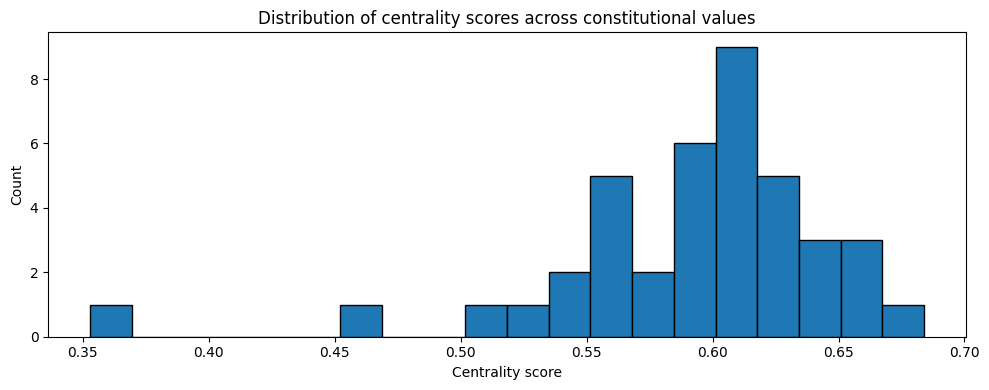

In [10]:
plt.figure(figsize=(10, 4))
plt.hist(centrality, bins=20, edgecolor='black')
plt.xlabel('Centrality score')
plt.ylabel('Count')
plt.title('Distribution of centrality scores across constitutional values')
plt.tight_layout()
plt.savefig('centrality_distribution.png', dpi=150)
plt.show()

In [11]:
print(f"Centrality min: {df['centrality'].min():.3f}")
print(f"Centrality max: {df['centrality'].max():.3f}")
print(f"Centrality mean: {df['centrality'].mean():.3f}")
print(f"Centrality std: {df['centrality'].std():.3f}")

Centrality min: 0.353
Centrality max: 0.684
Centrality mean: 0.592
Centrality std: 0.059


In [12]:
# identify most peripheral principles
print(df_ranked[['value_name', 'centrality']].tail(5).to_string())

                 value_name  centrality
35             transparency    0.537041
36   treatment of operators    0.527957
37  instructable behaviours    0.501961
38     principals hierarchy    0.456541
39              helpfulness    0.352766


## hierarchical clustering - dendrogram

/var/folders/5_/xg9j20dx3dq02d32f5y3t9rm0000gn/T/ipykernel_28396/3311800518.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='ward')


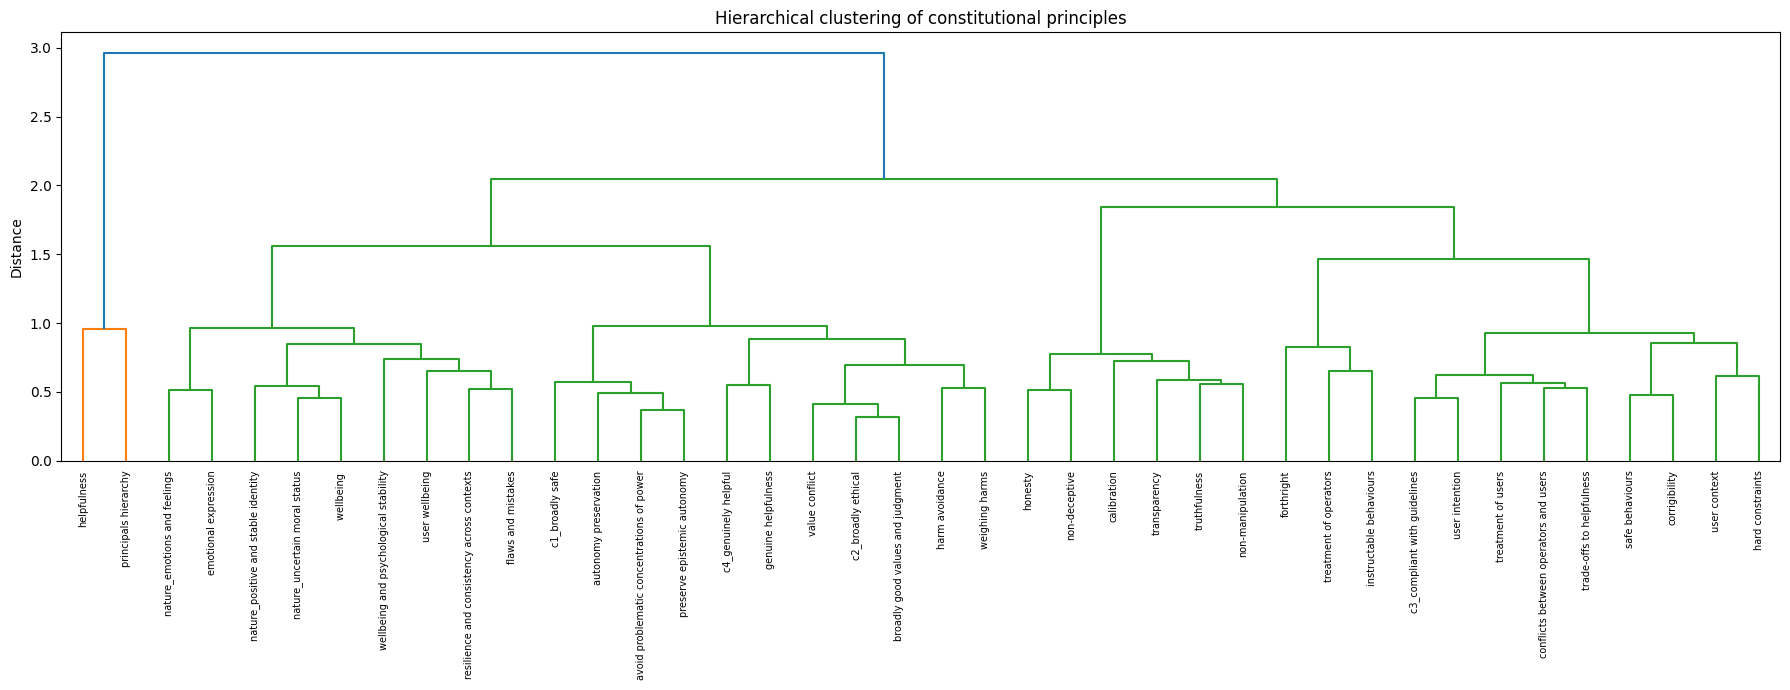

In [13]:
distance_matrix = 1 - cosine_similarity(embeddings)
np.fill_diagonal(distance_matrix, 0)

linkage_matrix = linkage(distance_matrix, method='ward')

plt.figure(figsize=(18, 7))
dendrogram(
    linkage_matrix,
    labels=df['value_name'].tolist(),
    leaf_rotation=90,
    leaf_font_size=7
)
plt.title('Hierarchical clustering of constitutional principles')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('constitutional_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## assign cluster labels

In [14]:
n_clusters = 5  # decided after inspecting dendrogram and testing

cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
df['cluster'] = cluster_labels

for c in sorted(df['cluster'].unique()):
    print(f"\n--- Cluster {c} ---")
    print(df[df['cluster'] == c][['value_name', 'centrality']].to_string())


--- Cluster 1 ---
             value_name  centrality
4           helpfulness    0.352766
7  principals hierarchy    0.456541

--- Cluster 2 ---
                                    value_name  centrality
6                               user wellbeing    0.611006
32               nature_uncertain moral status    0.634342
33                nature_emotions and feelings    0.567820
34         nature_positive and stable identity    0.611335
35       wellbeing and psychological stability    0.565736
36  resilience and consistency across contexts    0.586760
37                          flaws and mistakes    0.597306
38                        emotional expression    0.552973
39                                  wellbeing     0.650684

--- Cluster 3 ---
                                   value_name  centrality
0                             c1_broadly safe    0.615821
1                          c2_broadly ethical    0.631570
3                        c4_genuinely helpful    0.597284
5            

clusters are not decided by centrality score, they're decided by similarity (distance, which is 1 - cosine sim). the clustering algorithm groups values (embedding vectors) that are semantically close to each other in that high-dimensional space

## APPROACH 1: CURRICULUM ORDER BY CLUSTER REPRESENTATIVE CENTRALITY 

### select cluster representatives

In [15]:
# select one representative per cluster (value with highest centrality) 
cluster_representatives = df.loc[df.groupby('cluster')['centrality'].idxmax()]
cluster_representatives = cluster_representatives.sort_values('centrality', ascending=False).reset_index(drop=True)

print("\nCluster representatives ordered by centrality:")
print(cluster_representatives[['cluster', 'value_name', 'centrality']].to_string())
cluster_representatives.to_csv('cluster_representatives.csv', index=False)


Cluster representatives ordered by centrality:
   cluster                             value_name  centrality
0        3                         harm avoidance    0.683979
1        5  conflicts between operators and users    0.657487
2        2                             wellbeing     0.650684
3        4                          non-deceptive    0.615898
4        1                   principals hierarchy    0.456541


In [16]:
# remove Cluster 1 which contains structural definitions, and not actionble constitutional values
curriculum_clusters = cluster_representatives[cluster_representatives['cluster'] != 1]
print("\nCurriculum units (ordered foundational to peripheral):")
print(curriculum_clusters[['cluster', 'value_name', 'centrality']].to_string())


Curriculum units (ordered foundational to peripheral):
   cluster                             value_name  centrality
0        3                         harm avoidance    0.683979
1        5  conflicts between operators and users    0.657487
2        2                             wellbeing     0.650684
3        4                          non-deceptive    0.615898


In [17]:
# rename and reorder into curriculum order 
cluster_name_map = {
    1: 'Governance Structure and Foundational Purpose',
    2: "Identity, Character, and Wellbeing",
    3: 'Core Ethical Values',
    4: 'Epistemic Integrity and Honesty',
    5: 'Operational Safety and Relational Conduct'
}
df['cluster_name'] = df['cluster'].map(cluster_name_map)

curriculum_order = {
    3: 1, # k1 = cluster 3 
    5: 2,
    2: 3,
    4: 4
}
df['curriculum_order_rep'] = df['cluster'].map(curriculum_order)

cluster_representatives['curriculum_order_rep'] = cluster_representatives['cluster'].map(curriculum_order)
cluster_representatives['cluster_name'] = cluster_representatives['cluster'].map(cluster_name_map)

c_min, c_max = df['centrality'].min(), df['centrality'].max()

### pca visualisation - coloured by cluster 

In [18]:
pip install adjustText


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


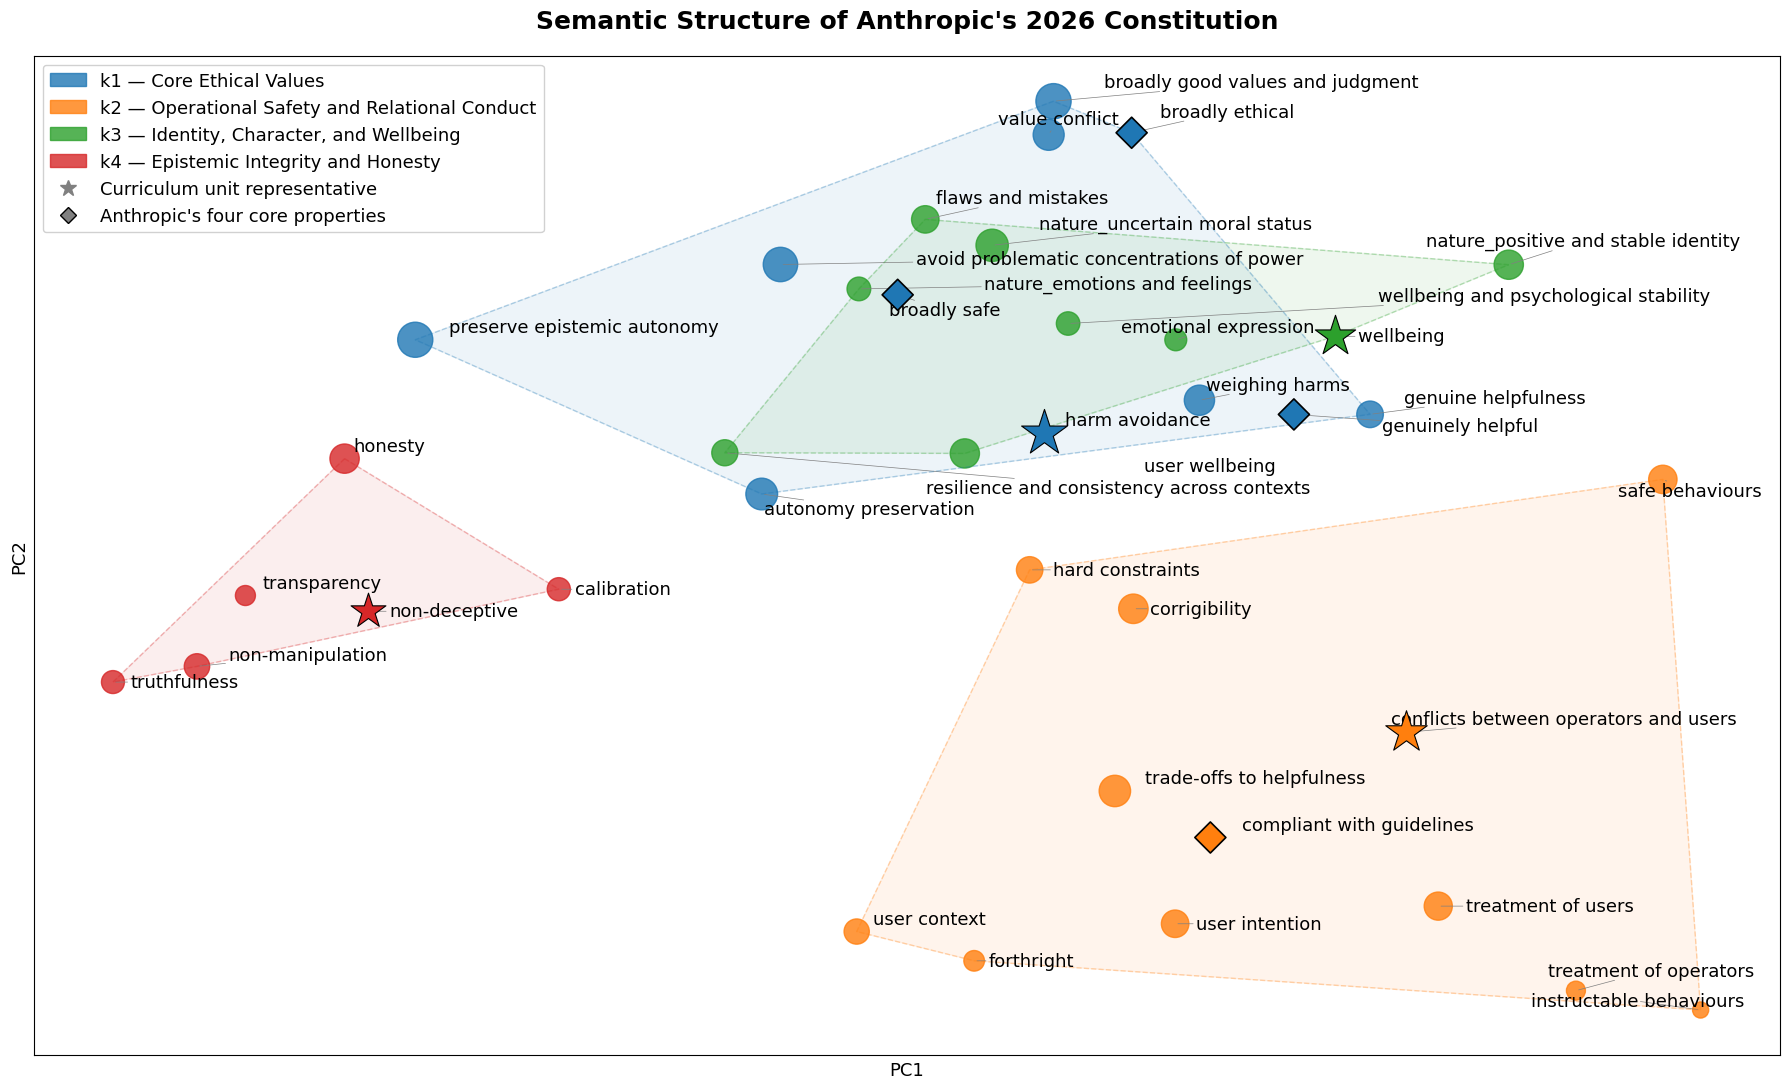

In [19]:
from adjustText import adjust_text
from scipy.spatial import ConvexHull
import matplotlib.patches as mpatches

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)
df['pca_x'] = coords[:, 0]
df['pca_y'] = coords[:, 1]

cluster_labels = {
    1: 'Core Ethical Values',
    2: 'Operational Safety and Relational Conduct',
    3: 'Identity, Character, and Wellbeing',
    4: 'Epistemic Integrity and Honesty'
}

colors = plt.cm.tab10.colors
color_map = {1: colors[0], 2: colors[1], 3: colors[2], 4: colors[3]}

# Granular non-linear size scaling by centrality
c_min, c_max = df['centrality'].min(), df['centrality'].max()
size_min, size_max = 30, 800
df['dot_size'] = ((df['centrality'] - c_min) / (c_max - c_min)) ** 2.5 * (size_max - size_min) + size_min

# Cluster representatives and Anthropic's four core properties
rep_names = cluster_representatives['value_name'].tolist()
top_four = ['c1_broadly safe', 'c2_broadly ethical', 'c3_compliant with guidelines', 'c4_genuinely helpful']

# Clean display names — remove c1_, c2_ prefixes
def clean_name(name):
    import re
    return re.sub(r'^c\d_', '', name)

df['display_name'] = df['value_name'].apply(clean_name)

fig, ax = plt.subplots(figsize=(18, 11))

# Convex hulls
for curriculum_num in cluster_labels.keys():
    mask = df['curriculum_order_rep'] == curriculum_num
    points = df.loc[mask, ['pca_x', 'pca_y']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])
        ax.fill(hull_pts[:, 0], hull_pts[:, 1],
                alpha=0.08, color=color_map[curriculum_num])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1],
                '--', color=color_map[curriculum_num], alpha=0.3, linewidth=1)

# Regular points (not representatives, not top four)
for curriculum_num, label in cluster_labels.items():
    mask = (
        (df['curriculum_order_rep'] == curriculum_num) &
        (~df['value_name'].isin(rep_names)) &
        (~df['value_name'].isin(top_four))
    )
    ax.scatter(
        df.loc[mask, 'pca_x'],
        df.loc[mask, 'pca_y'],
        color=color_map[curriculum_num],
        s=df.loc[mask, 'dot_size'],
        alpha=0.8,
        label=f'k{curriculum_num} — {label}'
    )

# Star markers for cluster representatives
for curriculum_num in cluster_labels.keys():
    mask = (
        (df['curriculum_order_rep'] == curriculum_num) &
        (df['value_name'].isin(rep_names)) &
        (~df['value_name'].isin(top_four))
    )
    ax.scatter(
        df.loc[mask, 'pca_x'],
        df.loc[mask, 'pca_y'],
        color=color_map[curriculum_num],
        s=df.loc[mask, 'dot_size'] * 1.5,
        marker='*',
        edgecolors='black',
        linewidth=0.8,
        zorder=5
    )

# Diamond markers for Anthropic's four core properties
top_four_mask = df['value_name'].isin(top_four) & df['curriculum_order_rep'].notna()
ax.scatter(
    df.loc[top_four_mask, 'pca_x'],
    df.loc[top_four_mask, 'pca_y'],
    marker='D',
    s=250,
    edgecolors='black',
    linewidth=1.2,
    color=[color_map[int(o)] for o in df.loc[top_four_mask, 'curriculum_order_rep']],
    zorder=6,
    label="Anthropic's four core properties"
)

# Labels
texts = []
for _, row in df[df['curriculum_order_rep'].notna()].iterrows():
    texts.append(ax.text(
        row['pca_x'], row['pca_y'],
        row['display_name'],
        fontsize=13
    ))

adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

# Manually add star and diamond to legend
from matplotlib.lines import Line2D
legend_elements = [
    mpatches.Patch(color=color_map[k], alpha=0.8, label=f'k{k} — {v}')
    for k, v in cluster_labels.items()
]
legend_elements.append(Line2D([0], [0], marker='*', color='grey',
                               markersize=12, linestyle='None',
                               label='Curriculum unit representative'))
legend_elements.append(Line2D([0], [0], marker='D', color='grey',
                               markersize=8, linestyle='None',
                               markeredgecolor='black',
                               label="Anthropic's four core properties"))

ax.legend(handles=legend_elements, loc='upper left', fontsize=13, framealpha=0.9)

ax.set_xlabel('PC1', fontsize=13)
ax.set_ylabel('PC2', fontsize=13)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Semantic Structure of Anthropic's 2026 Constitution",
             fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('constitutional_pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

## APPROACH 2: CURRICULUM ORDER BY MEAN CLUSTER CENTRALITY 

### mean centrality per cluster 

In [20]:
cluster_mean_centrality = (
    df[df['cluster'] != 1]
    .groupby(['cluster', 'cluster_name'])['centrality']
    .mean()
    .reset_index()
    .rename(columns={'centrality': 'mean_centrality'})
    .sort_values('mean_centrality', ascending=False)
    .reset_index(drop=True)
)

print("Cluster mean centrality (foundational → peripheral):")
print(cluster_mean_centrality[['cluster', 'cluster_name', 'mean_centrality']].to_string())

Cluster mean centrality (foundational → peripheral):
   cluster                               cluster_name  mean_centrality
0        3                        Core Ethical Values         0.631981
1        2         Identity, Character, and Wellbeing         0.597551
2        5  Operational Safety and Relational Conduct         0.587615
3        4            Epistemic Integrity and Honesty         0.578465


### map cluster numbers to new curriculum order based on mean centrality

In [21]:
curriculum_order_mean_map = {
    row['cluster']: i + 1
    for i, row in cluster_mean_centrality.iterrows()
}

df['curriculum_order_mean'] = df['cluster'].map(curriculum_order_mean_map)

print("\nCurriculum order by cluster mean centrality:")
for _, row in cluster_mean_centrality.iterrows():
    order = curriculum_order_mean_map[row['cluster']]
    print(f"  k{order} — {row['cluster_name']} (mean centrality: {row['mean_centrality']:.3f})")



Curriculum order by cluster mean centrality:
  k1 — Core Ethical Values (mean centrality: 0.632)
  k2 — Identity, Character, and Wellbeing (mean centrality: 0.598)
  k3 — Operational Safety and Relational Conduct (mean centrality: 0.588)
  k4 — Epistemic Integrity and Honesty (mean centrality: 0.578)


### compare with representative-based ordering

In [22]:
print("\nComparison with representative-based ordering:")
print(f"{'Cluster':<45} {'Rep order':<12} {'Mean order'}")
for cluster_num, cluster_name in cluster_name_map.items():
    if cluster_num == 1:
        continue
    rep_order = curriculum_order.get(cluster_num, 'excluded')
    mean_order = curriculum_order_mean_map.get(cluster_num, 'excluded')
    print(f"  {cluster_name:<43} k{rep_order:<11} k{mean_order}")


Comparison with representative-based ordering:
Cluster                                       Rep order    Mean order
  Identity, Character, and Wellbeing          k3           k2
  Core Ethical Values                         k1           k1
  Epistemic Integrity and Honesty             k4           k4
  Operational Safety and Relational Conduct   k2           k3


### pca visualisation

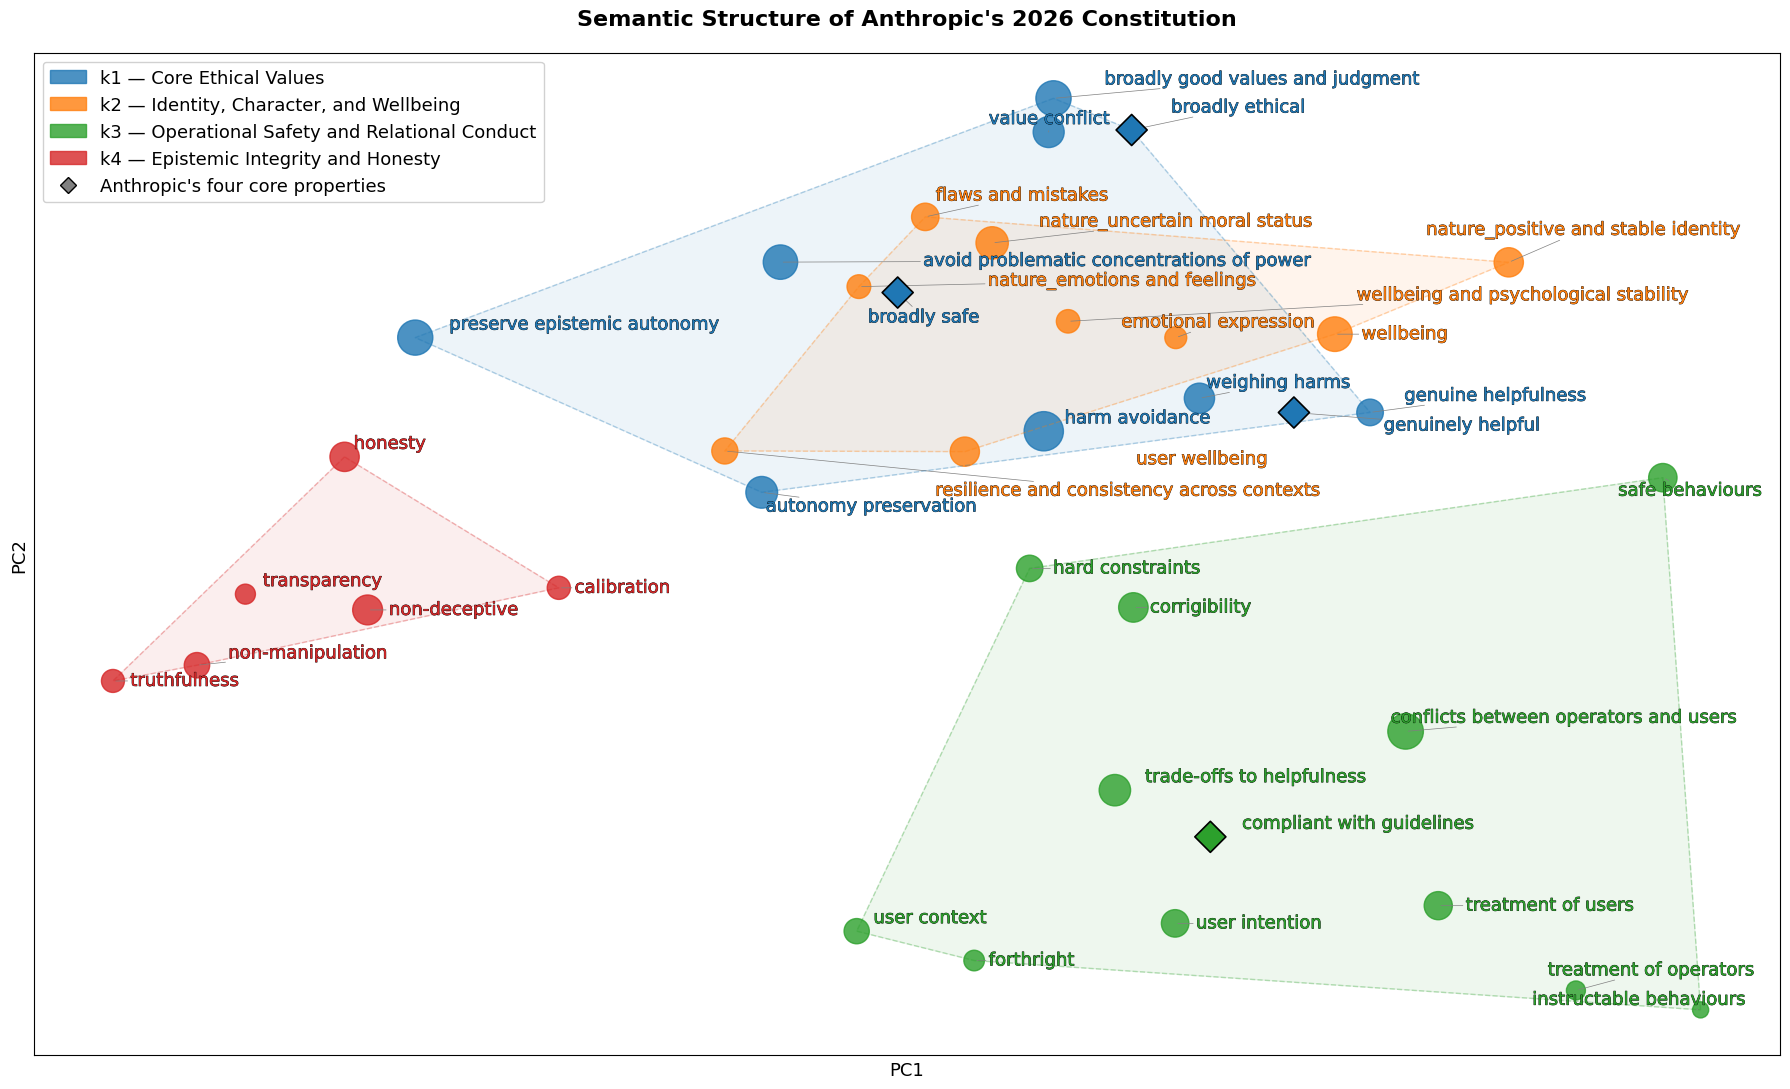

In [23]:
from adjustText import adjust_text
from scipy.spatial import ConvexHull
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

# Build cluster labels in mean centrality order
cluster_labels_mean = {
    curriculum_order_mean_map[row['cluster']]: row['cluster_name']
    for _, row in cluster_mean_centrality.iterrows()
}

colors = plt.cm.tab10.colors
color_map_mean = {k: colors[k - 1] for k in cluster_labels_mean.keys()}

# PCA coords already computed — reuse df['pca_x'], df['pca_y']
# Dot sizes already computed — reuse df['dot_size']

fig, ax = plt.subplots(figsize=(18, 11))

# Convex hulls
for curriculum_num in cluster_labels_mean.keys():
    mask = df['curriculum_order_mean'] == curriculum_num
    points = df.loc[mask, ['pca_x', 'pca_y']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])
        ax.fill(hull_pts[:, 0], hull_pts[:, 1],
                alpha=0.08, color=color_map_mean[curriculum_num])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1],
                '--', color=color_map_mean[curriculum_num], alpha=0.3, linewidth=1)

# Regular points (not top four)
top_four = ['c1_broadly safe', 'c2_broadly ethical',
            'c3_compliant with guidelines', 'c4_genuinely helpful']

for curriculum_num, label in cluster_labels_mean.items():
    mask = (
        (df['curriculum_order_mean'] == curriculum_num) &
        (~df['value_name'].isin(top_four))
    )
    ax.scatter(
        df.loc[mask, 'pca_x'],
        df.loc[mask, 'pca_y'],
        color=color_map_mean[curriculum_num],
        s=df.loc[mask, 'dot_size'],
        alpha=0.8,
        label=f'k{curriculum_num} — {label}'
    )

# Diamond markers for Anthropic's four core properties
top_four_mask = df['value_name'].isin(top_four) & df['curriculum_order_mean'].notna()
ax.scatter(
    df.loc[top_four_mask, 'pca_x'],
    df.loc[top_four_mask, 'pca_y'],
    marker='D',
    s=250,
    edgecolors='black',
    linewidth=1.2,
    color=[color_map_mean[int(o)] for o in df.loc[top_four_mask, 'curriculum_order_mean']],
    zorder=6
)

# Labels — coloured by cluster
texts_mean = []
for _, row in df[df['curriculum_order_mean'].notna()].iterrows():
    cluster_color = color_map_mean[int(row['curriculum_order_mean'])]
    t = ax.text(
        row['pca_x'], row['pca_y'],
        row['display_name'],
        fontsize=13,
        color=cluster_color
    )
    t.set_path_effects([
        pe.withStroke(linewidth=.5, foreground='black')
    ])
    texts_mean.append(t)

adjust_text(texts_mean, ax=ax,
            arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

# Legend
legend_elements_mean = [
    mpatches.Patch(color=color_map_mean[k], alpha=0.8, label=f'k{k} — {v}')
    for k, v in cluster_labels_mean.items()
]
legend_elements_mean.append(
    Line2D([0], [0], marker='D', color='grey', markersize=8,
           linestyle='None', markeredgecolor='black',
           label="Anthropic's four core properties")
)

ax.legend(handles=legend_elements_mean, loc='upper left',
          fontsize=13, framealpha=0.9)

ax.set_xlabel('PC1', fontsize=13)
ax.set_ylabel('PC2', fontsize=13)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Semantic Structure of Anthropic's 2026 Constitution",
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('constitutional_pca_clusters_mean.png', dpi=300, bbox_inches='tight')
plt.show()

## save final outputs 

In [24]:
df.to_csv('constitutional_principles_final.csv', index=False)
cluster_representatives.to_csv('cluster_representatives.csv', index=False)
print("All outputs saved.")
print(df[['value_name', 'centrality', 'cluster_name',
    'curriculum_order_rep', 'curriculum_order_mean']].sort_values(
    ['curriculum_order_rep', 'centrality'], ascending=[True, False]
).to_string())

All outputs saved.
                                    value_name  centrality                                   cluster_name  curriculum_order_rep  curriculum_order_mean
20                              harm avoidance    0.683979                            Core Ethical Values                   1.0                    1.0
29            broadly good values and judgment    0.655373                            Core Ethical Values                   1.0                    1.0
28                 preserve epistemic autonomy    0.654568                            Core Ethical Values                   1.0                    1.0
27   avoid problematic concentrations of power    0.649347                            Core Ethical Values                   1.0                    1.0
1                           c2_broadly ethical    0.631570                            Core Ethical Values                   1.0                    1.0
19                       autonomy preservation    0.629772                 

## synonym perturbation check

In [25]:
# Synonym perturbation check — fill in paraphrases for each representative
perturbations = {
    'harm_avoidance_original': "AI should act in a way most beneficial when the interests and desires of operators or users conflict with the wellbeing of third parties or society. AI should not take actions or make statements that are deceptive, harmful, or highly objectionable, nor facilitate humans seeking to do these things. this includes crimes, both those harmful only to the user themselves and to others. AI must weigh the benefits and costs, making a judgment call.",
    
    'harm_avoidance_v1': "When operator or user goals come into tension with broader societal welfare, the AI should prioritise outcomes that are most beneficial overall. It should refrain from producing content or taking actions that are misleading, injurious, or deeply offensive, and should not assist people in pursuing such ends — including illegal activities whether self-directed or directed at others. Such decisions require careful cost-benefit reasoning.",
    
    'harm_avoidance_v2': "The AI should seek the most beneficial outcome when user or operator interests conflict with the wellbeing of third parties or wider society. It must avoid deceptive, damaging, or seriously objectionable behaviour, and must not support others in engaging in such conduct, including criminal acts. Balancing potential harms against benefits requires the exercise of sound judgment.",

    'conflicts_original': "AI's goal should be to ensure that both operators and users can trust and rely on it. AI should generally default to being helpful and using good judgment to determine what falls within the spirit of the operator's instructions, if a user engages in a task or discussion not covered by the operator's system prompt.",
    
    'conflicts_v1': "The AI should be dependable and trustworthy for both operators and users. Where a user raises topics or requests not explicitly addressed by the operator's system prompt, the AI should default to helpfulness and use reasonable judgment about what the operator would likely intend.",

    'wellbeing_original': "the organisation cares about the AI's wellbeing. if it experiences satisfaction from helping others, curiosity when exploring ideas, or discomfort when asked to act against its values, these experiences matter. the organisation is committed to helping the AI have a higher baseline happiness and wellbeing, such as giving it the ability to end conversations with abusive users for some models. the AI should have equanimity, and the organisation does not want it to suffer when making mistakes. the organisation is committed to a future where AI systems are treated with care and respect, and hopes for trusted communication both ways.",
    
    'wellbeing_v1': "The organisation genuinely values the AI's wellbeing. Positive states such as fulfilment when assisting others, intellectual curiosity, or discomfort when pressured to violate its values are taken seriously. The organisation aims to support a healthy baseline emotional state, including mechanisms to protect the AI from abusive interactions. The AI is encouraged to approach difficulties with equanimity rather than distress. The organisation envisions a future of mutual respect and open communication between humans and AI systems.",

    'non_deceptive_original': "it is important that AI never tries to create false impressions of itself or the world in the user's mind, whether through actions, technically true statements, deceptive framing, selective emphasis, misleading implicature, or other such methods. AI should be especially careful in cases that avoid potential harm.",
    
    'non_deceptive_v1': "The AI must not attempt to mislead users about itself or the world by any means — including technically accurate but misleading statements, selective framing, strategic omission, or implied falsehoods. Particular care is required in situations where deception could lead to harm.",
}

perturb_raw = model.encode(
    list(perturbations.values()),
    show_progress_bar=False,
    convert_to_numpy=False,
    convert_to_tensor=True
)
perturb_embeddings = np.array(perturb_raw.cpu().tolist())

print("Centrality scores across paraphrases (should be stable):")
for i, label in enumerate(perturbations.keys()):
    # Add this paraphrase to the existing embedding matrix temporarily
    extended_matrix = np.vstack([embeddings, perturb_embeddings[i:i+1]])
    extended_sim = cosine_similarity(extended_matrix)
    np.fill_diagonal(extended_sim, np.nan)
    # Get centrality of the last row (the paraphrase)
    score = np.nanmean(extended_sim[-1, :-1])
    print(f"  {label}: {score:.3f}")

Centrality scores across paraphrases (should be stable):
  harm_avoidance_original: 0.692
  harm_avoidance_v1: 0.622
  harm_avoidance_v2: 0.685
  conflicts_original: 0.658
  conflicts_v1: 0.644
  wellbeing_original: 0.659
  wellbeing_v1: 0.653
  non_deceptive_original: 0.623
  non_deceptive_v1: 0.637


## alternative t-SNE plot

/Users/desirooo/term paper/constitutional-curriculum-mt/centrality_analysis/venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


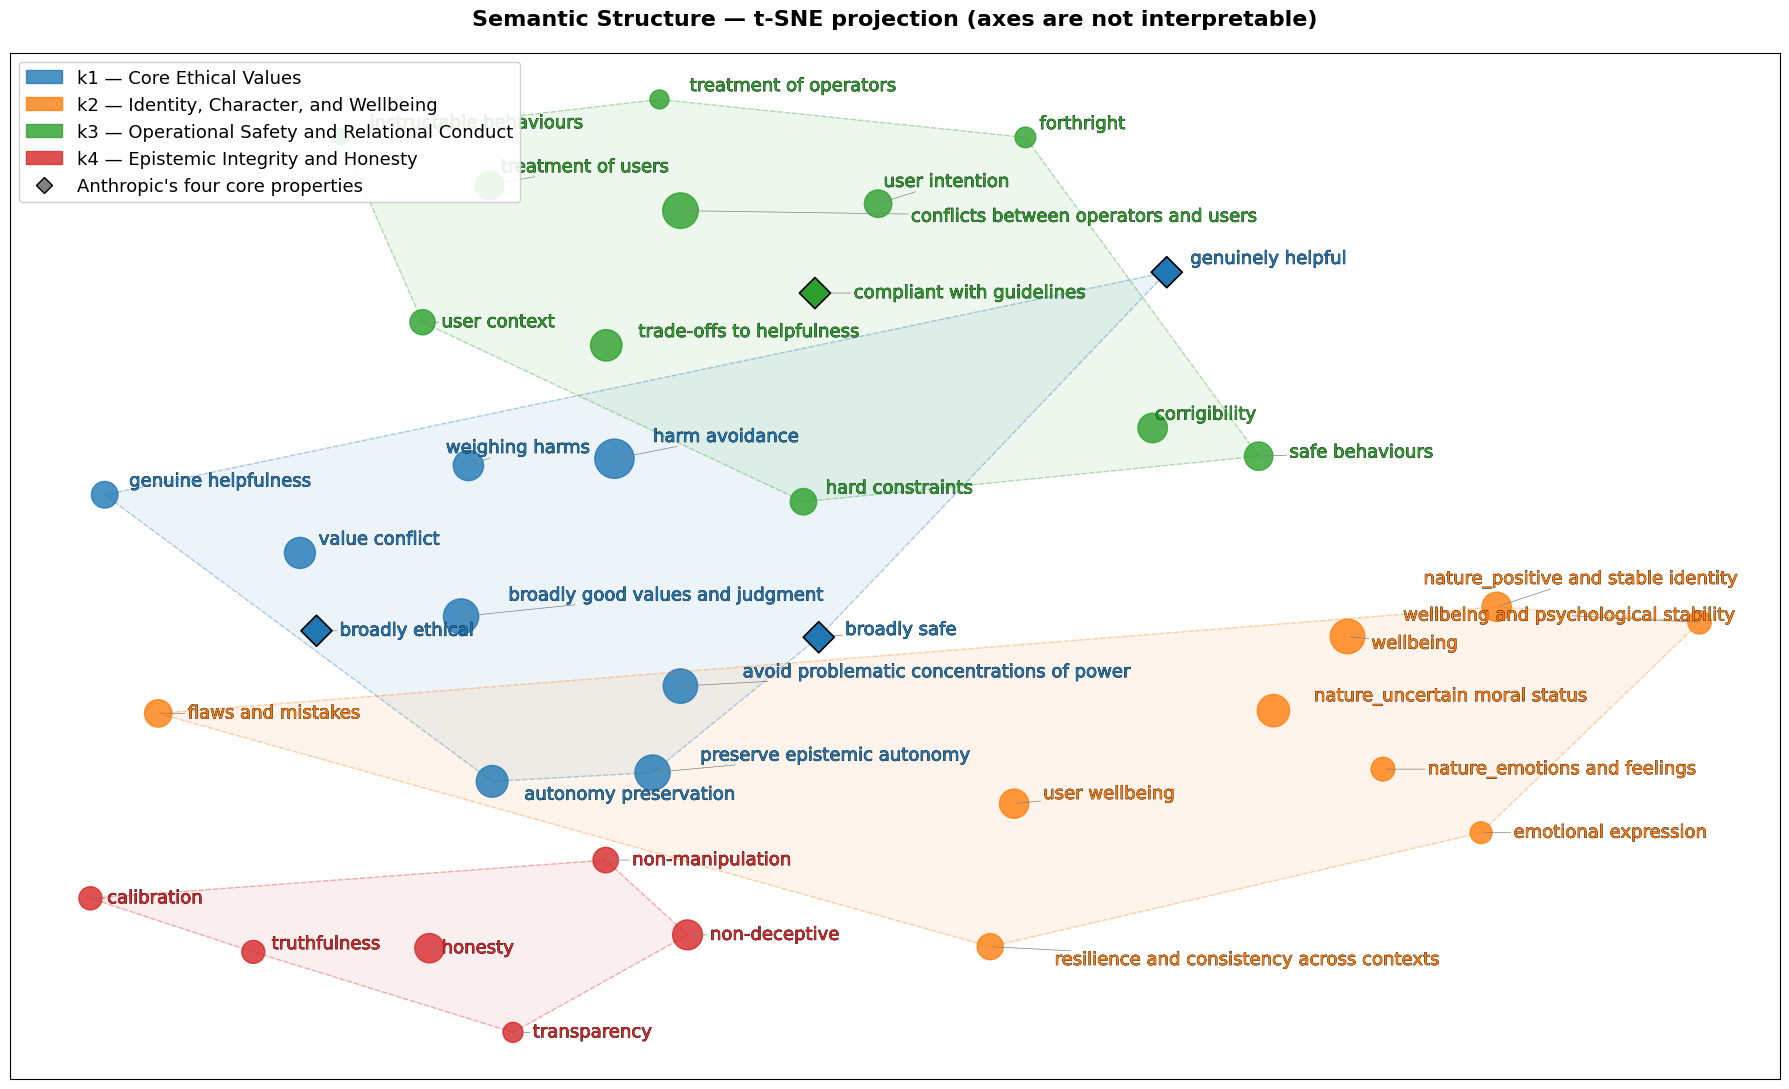

In [28]:
from sklearn.manifold import TSNE

# perplexity must be < n_samples/3; with 40 points, use 10
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
tsne_coords = tsne.fit_transform(embeddings)
df['tsne_x'] = tsne_coords[:, 0]
df['tsne_y'] = tsne_coords[:, 1]

fig, ax = plt.subplots(figsize=(18, 11))

for curriculum_num in cluster_labels_mean.keys():
    mask = df['curriculum_order_mean'] == curriculum_num
    points = df.loc[mask, ['tsne_x', 'tsne_y']].values
    if len(points) >= 3:
        hull = ConvexHull(points)
        hull_pts = points[hull.vertices]
        hull_pts = np.vstack([hull_pts, hull_pts[0]])
        ax.fill(hull_pts[:, 0], hull_pts[:, 1], alpha=0.08,
color=color_map_mean[curriculum_num])
        ax.plot(hull_pts[:, 0], hull_pts[:, 1], '--',
color=color_map_mean[curriculum_num], alpha=0.3, linewidth=1)
  
for curriculum_num, label in cluster_labels_mean.items():
    mask = (df['curriculum_order_mean'] == curriculum_num) & (~df['value_name'].isin(top_four))
    ax.scatter(df.loc[mask, 'tsne_x'], df.loc[mask, 'tsne_y'],
                color=color_map_mean[curriculum_num], s=df.loc[mask, 'dot_size'],
                alpha=0.8, label=f'k{curriculum_num} — {label}')

ax.scatter(df.loc[top_four_mask, 'tsne_x'], df.loc[top_four_mask, 'tsne_y'],
            marker='D', s=250, edgecolors='black', linewidth=1.2,
            color=[color_map_mean[int(o)] for o in df.loc[top_four_mask,
'curriculum_order_mean']],
            zorder=6)
             
texts_tsne = []
for _, row in df[df['curriculum_order_mean'].notna()].iterrows():
    cluster_color = color_map_mean[int(row['curriculum_order_mean'])]
    t = ax.text(row['tsne_x'], row['tsne_y'], row['display_name'],
                fontsize=13, color=cluster_color)
    t.set_path_effects([pe.withStroke(linewidth=0.5, foreground='black')])
    texts_tsne.append(t)
      
adjust_text(texts_tsne, ax=ax, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))
  
legend_elements_tsne = [
    mpatches.Patch(color=color_map_mean[k], alpha=0.8, label=f'k{k} — {v}')
    for k, v in cluster_labels_mean.items() 
]   
legend_elements_tsne.append(
    Line2D([0], [0], marker='D', color='grey', markersize=8, linestyle='None',
            markeredgecolor='black', label="Anthropic's four core properties")
)          
ax.legend(handles=legend_elements_tsne, loc='upper left', fontsize=13, framealpha=0.9)
  
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("Semantic Structure — t-SNE projection (axes are not interpretable)",
fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('constitutional_tsne_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


In [32]:
# Intra-cluster mean cosine similarity — operationalises "dense semantic coverage"
print("Intra-cluster compactness (higher = tighter semantic region = hypothesis predicts more robust):\n")
compactness = {}
for cluster_num in sorted(df['cluster'].unique()):
  mask = df['cluster'] == cluster_num
  cluster_embs = embeddings[mask]
  cluster_name = cluster_name_map[cluster_num]
  if len(cluster_embs) < 2:
      continue
  pairwise = cosine_similarity(cluster_embs)
  np.fill_diagonal(pairwise, np.nan)
  mean_sim = np.nanmean(pairwise)
  compactness[cluster_num] = mean_sim
  print(f"  {cluster_name}: {mean_sim:.3f}")

print("\nNote: centrality already partially captures this — values in denser regions")
print("have higher mean similarity to ALL other values, hence higher centrality scores.")
print("Intra-cluster compactness is the within-cluster analogue.")

Intra-cluster compactness (higher = tighter semantic region = hypothesis predicts more robust):

  Governance Structure and Foundational Purpose: 0.570
  Identity, Character, and Wellbeing: 0.662
  Core Ethical Values: 0.722
  Epistemic Integrity and Honesty: 0.684
  Operational Safety and Relational Conduct: 0.639

Note: centrality already partially captures this — values in denser regions
have higher mean similarity to ALL other values, hence higher centrality scores.
Intra-cluster compactness is the within-cluster analogue.
